In [2]:
# import modules

import os
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array

workspace = 'data/COVID-19_Radiography_Dataset/'

Matplotlib is building the font cache; this may take a moment.


In [ ]:
def load_img_as_np_arr(img_dir):

    img_arr_list = []

    #for file in os.listdir(img_dir):    
    for filename in sorted(os.listdir(img_dir)): # j'ai ajouter sorted pour assurer l'ordre
        #filename = os.fsdecode(file)
        if filename.endswith(".png"): 
            #img = load_img(os.path.abspath(img_dir)+b'/'+file)
            img = load_img(os.path.join(img_dir, filename)) # join(img_dir, filename) pour ça soit compatible toutes OS
            arr = img_to_array(img)
            img_arr_list.append(arr)
            continue
        else:
            print(f'{filename} is not a png file')
            continue

    return np.array(img_arr_list)


In [11]:
def display_img_np_arr(img_arr):
    print(type(img_arr))
    print(img_arr.dtype)
    print(img_arr.shape)
    print(f"Value range: [{img_arr.min()}, {img_arr.max()}]")   

In [12]:
covid_img_dir = os.fsencode(workspace+'COVID/images/')

covid_img_arr = load_img_as_np_arr(covid_img_dir)

display_img_np_arr(covid_img_arr)

<class 'numpy.ndarray'>
float32
(3616, 299, 299, 3)
Value range: [0.0, 255.0]


In [13]:
covid_msk_dir = os.fsencode(workspace+'COVID/masks/')

covid_msk_arr = load_img_as_np_arr(covid_msk_dir)

display_img_np_arr(covid_msk_arr)

<class 'numpy.ndarray'>
float32
(3616, 256, 256, 3)
Value range: [0.0, 255.0]


In [14]:
lung_opa_img_dir = os.fsencode(workspace+'Lung_Opacity/images/')

lung_opa_img_arr = load_img_as_np_arr(lung_opa_img_dir)

display_img_np_arr(lung_opa_img_arr)

<class 'numpy.ndarray'>
float32
(6012, 299, 299, 3)
Value range: [0.0, 255.0]


In [15]:
lung_opa_msk_dir = os.fsencode(workspace+'Lung_Opacity/masks/')

lung_opa_msk_arr = load_img_as_np_arr(lung_opa_msk_dir)

display_img_np_arr(lung_opa_msk_arr)

<class 'numpy.ndarray'>
float32
(6012, 256, 256, 3)
Value range: [0.0, 255.0]


In [16]:
normal_img_dir = os.fsencode(workspace+'Normal/images/')

normal_img_arr = load_img_as_np_arr(normal_img_dir)

display_img_np_arr(normal_img_arr)

<class 'numpy.ndarray'>
float32
(10192, 299, 299, 3)
Value range: [0.0, 255.0]


In [17]:
normal_msk_dir = os.fsencode(workspace+'Normal/masks/')

normal_msk_arr = load_img_as_np_arr(normal_msk_dir)

display_img_np_arr(normal_msk_arr)

<class 'numpy.ndarray'>
float32
(10192, 256, 256, 3)
Value range: [0.0, 255.0]


In [18]:
pneumo_img_dir = os.fsencode(workspace+'Viral Pneumonia/images/')

pneumo_img_arr = load_img_as_np_arr(pneumo_img_dir)

display_img_np_arr(pneumo_img_arr)

<class 'numpy.ndarray'>
float32
(1345, 299, 299, 3)
Value range: [0.0, 255.0]


In [20]:
pneumo_msk_dir = os.fsencode(workspace+'Viral Pneumonia/masks/')

pneumo_msk_arr = load_img_as_np_arr(pneumo_msk_dir)

display_img_np_arr(pneumo_msk_arr)

<class 'numpy.ndarray'>
float32
(1345, 256, 256, 3)
Value range: [0.0, 255.0]


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# preparation pour ploat bar
class_counts = pd.DataFrame({
    "class": ["COVID", "Lung Opacity", "Normal", "Viral Pneumonia"],
    "count": [
        covid_img_arr.shape[0],
        lung_opa_img_arr.shape[0],
        normal_img_arr.shape[0],
        pneumo_img_arr.shape[0]
    ]
})

class_counts

,class,count
0,COVID,3616
1,Lung Opacity,6012
2,Normal,10192
3,Viral Pneumonia,1345


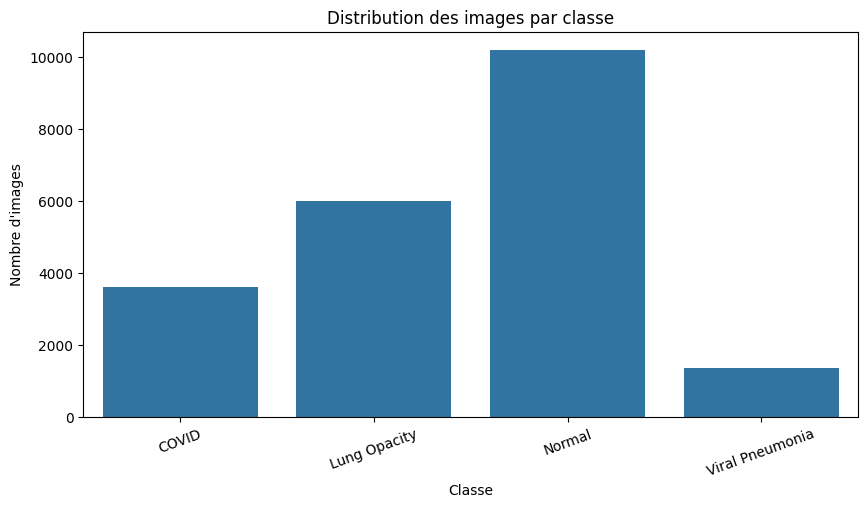

In [26]:
# visu bar count pour chaque classe
plt.figure(figsize=(10, 5))

sns.barplot(
    data=class_counts,
    x="class",
    y="count"
)

plt.title("Distribution des images par classe")
plt.xlabel("Classe")
plt.ylabel("Nombre d'images")
plt.xticks(rotation=20)
plt.show()

#interpretation: On observe un déséquilibre entre les classes. La classe Normal est majoritaire, tandis que la classe Viral Pneumonia est la moins représentée. 
# Ce déséquilibre devra être pris en compte lors de la préparation des données et de l'entraînement du modèle.

In [27]:
def get_pixel_stats(class_image_arrays):
    
    stats = []

    for class_name, arr in class_image_arrays.items():
        stats.append({
            "class": class_name,
            "n_images": arr.shape[0],
            "pixel_min": arr.min(),
            "pixel_max": arr.max(),
            "pixel_mean": arr.mean(),
            "pixel_std": arr.std()
        })

    return pd.DataFrame(stats)

In [28]:
class_image_arrays = {
    "COVID": covid_img_arr,
    "Lung Opacity": lung_opa_img_arr,
    "Normal": normal_img_arr,
    "Viral Pneumonia": pneumo_img_arr
}

pixel_stats_df = get_pixel_stats(class_image_arrays)

pixel_stats_df

,class,n_images,pixel_min,pixel_max,pixel_mean,pixel_std
0,COVID,3616,0.0,255.0,139.521210,61.907127
1,Lung Opacity,6012,0.0,255.0,126.021591,62.817848
2,Normal,10192,0.0,255.0,129.389801,66.216866
3,Viral Pneumonia,1345,0.0,255.0,125.369637,62.666641


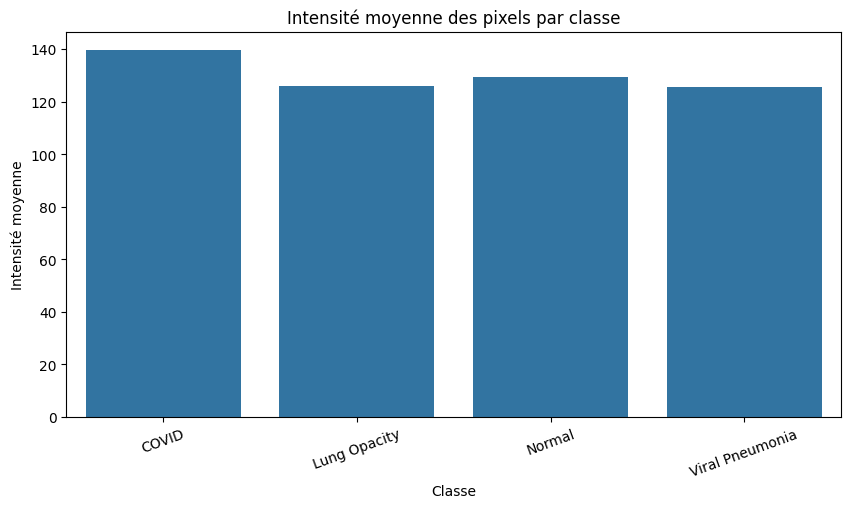

In [29]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=pixel_stats_df,
    x="class",
    y="pixel_mean"
)

plt.title("Intensité moyenne des pixels par classe")
plt.xlabel("Classe")
plt.ylabel("Intensité moyenne")
plt.xticks(rotation=20)
plt.show()

In [ ]:
## interprétation:
# La classe COVID présente l'intensité moyenne la plus élevée, ce qui signifie que ses images sont globalement 
# plus claires que celles des autres classes. 
# À l'inverse, les classes Lung Opacity et Viral Pneumonia ont une luminosité moyenne plus faible.

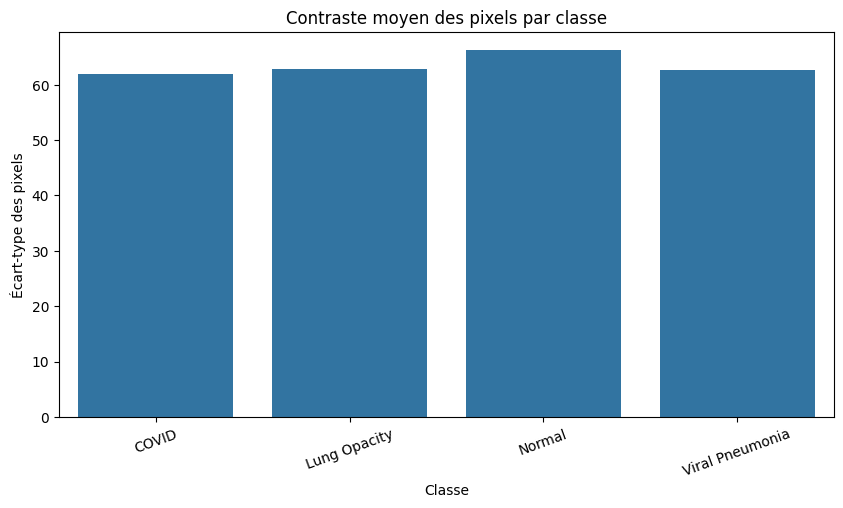

In [30]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=pixel_stats_df,
    x="class",
    y="pixel_std"
)

plt.title("Contraste moyen des pixels par classe")
plt.xlabel("Classe")
plt.ylabel("Écart-type des pixels")
plt.xticks(rotation=20)
plt.show()

In [ ]:
## interprétation:
# L'écart-type des pixels, utilisé comme approximation du contraste, est légèrement plus élevé pour la classe Normal. 
# Cela suggère que les images Normal présentent davantage de variations d'intensité entre zones sombres et zones claires.

In [31]:
def get_image_level_pixel_stats(class_image_arrays):
    
    stats = []

    for class_name, arr in class_image_arrays.items():
        for i in range(arr.shape[0]):
            img = arr[i]
            
            stats.append({
                "class": class_name,
                "image_index": i,
                "pixel_mean": img.mean(),
                "pixel_std": img.std()
            })

    return pd.DataFrame(stats)


image_level_stats_df = get_image_level_pixel_stats(class_image_arrays)

image_level_stats_df.head()

,class,image_index,pixel_mean,pixel_std
0,COVID,0,145.896851,51.816631
1,COVID,1,148.214218,65.081375
2,COVID,2,173.977707,54.045704
3,COVID,3,133.255096,44.188393
4,COVID,4,138.800018,53.869347


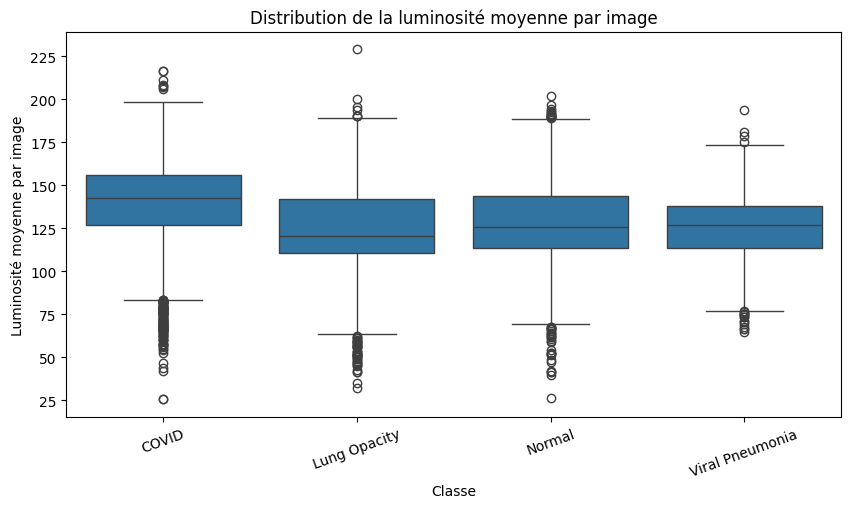

In [32]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=image_level_stats_df,
    x="class",
    y="pixel_mean"
)

plt.title("Distribution de la luminosité moyenne par image")
plt.xlabel("Classe")
plt.ylabel("Luminosité moyenne par image")
plt.xticks(rotation=20)
plt.show()

In [ ]:
## interprétation:
# Le boxplot de la luminosité moyenne par image montre que la classe COVID présente une luminosité médiane plus 
# élevée que les autres classes. Les classes Lung Opacity, Normal et Viral Pneumonia ont des distributions plus 
# proches entre elles, avec une luminosité globalement plus faible.
# Cependant, les distributions se chevauchent fortement, ce qui indique que la luminosité seule ne permet pas de 
# distinguer clairement les classes.

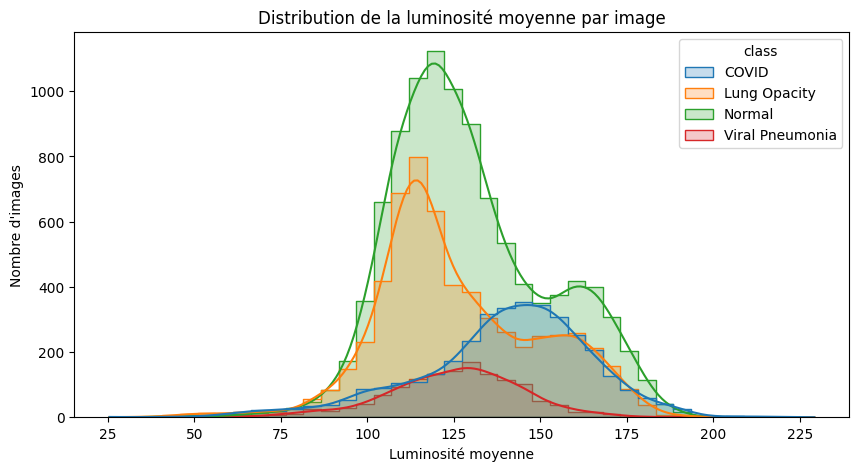

In [35]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=image_level_stats_df,
    x="pixel_mean",
    hue="class",
    bins=40,
    kde=True,
    element="step"
)

plt.title("Distribution de la luminosité moyenne par image")
plt.xlabel("Luminosité moyenne")
plt.ylabel("Nombre d'images")
plt.show()

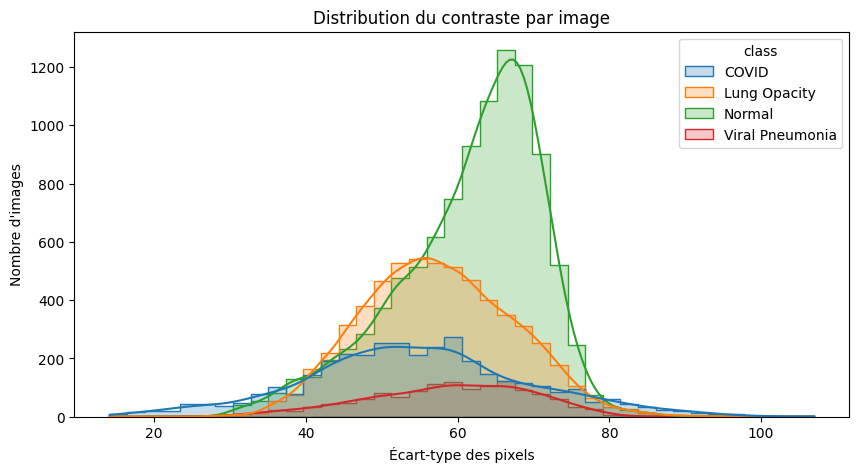

In [36]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=image_level_stats_df,
    x="pixel_std",
    hue="class",
    bins=40,
    kde=True,
    element="step"
)

plt.title("Distribution du contraste par image")
plt.xlabel("Écart-type des pixels")
plt.ylabel("Nombre d'images")
plt.show()

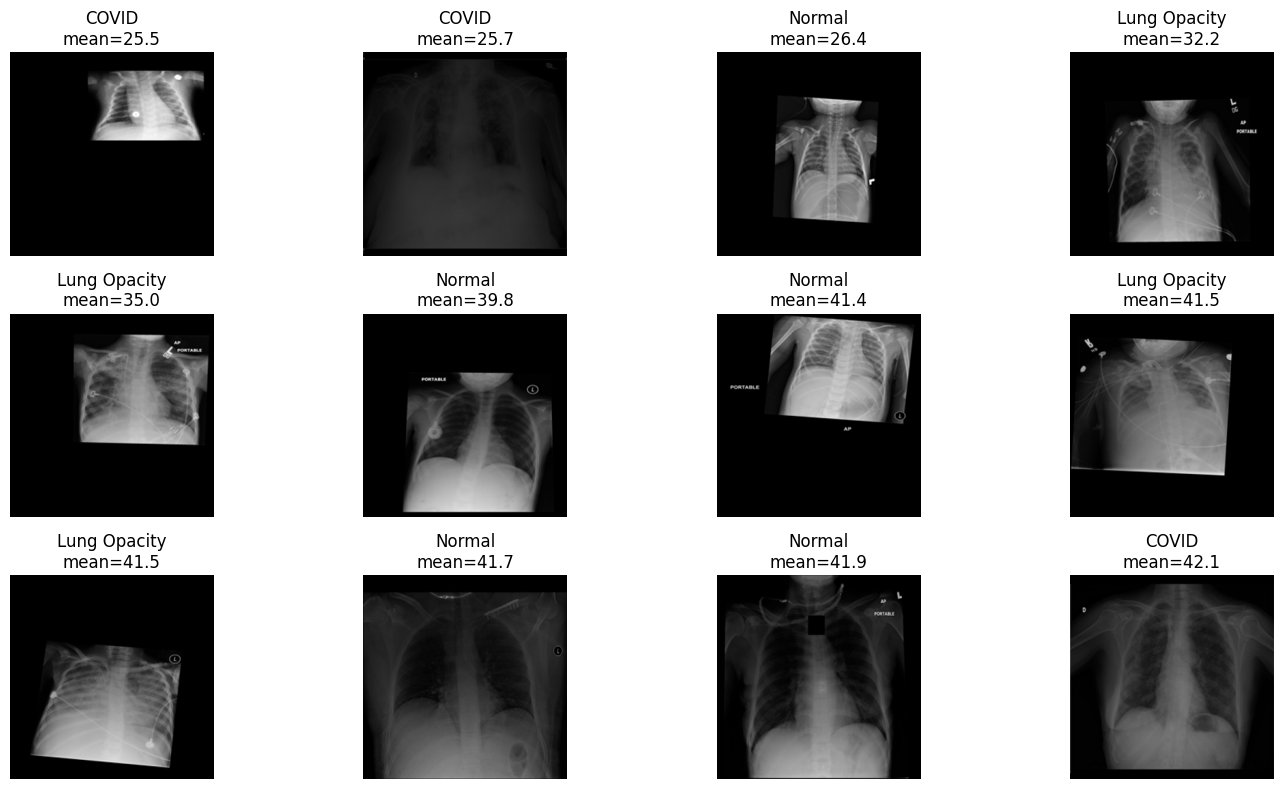

In [33]:
dark_images = image_level_stats_df.sort_values("pixel_mean").head(12)

plt.figure(figsize=(15, 8))

for i, (_, row) in enumerate(dark_images.iterrows(), start=1):
    img = class_image_arrays[row["class"]][int(row["image_index"])]
    
    plt.subplot(3, 4, i)
    plt.imshow(img.astype("uint8"))
    plt.title(f'{row["class"]}\nmean={row["pixel_mean"]:.1f}')
    plt.axis("off")

plt.tight_layout()
plt.show()

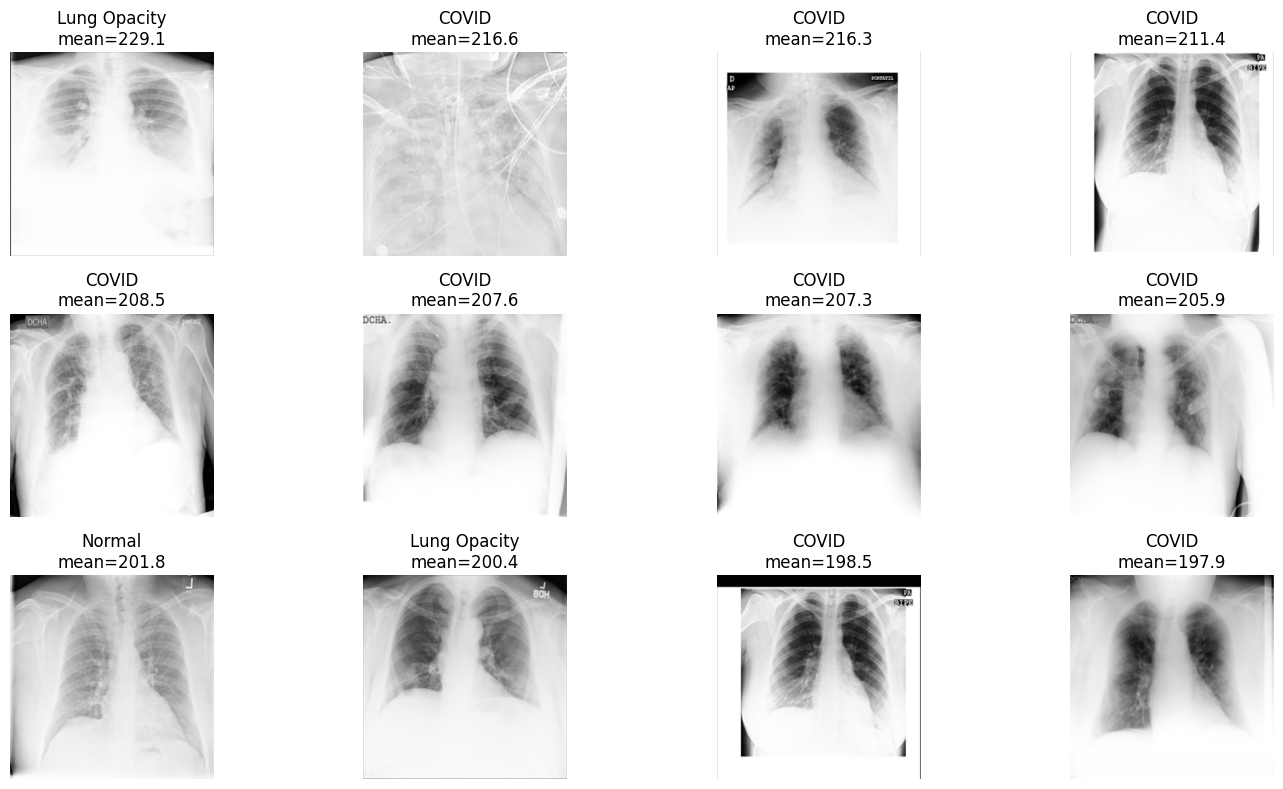

In [34]:
bright_images = image_level_stats_df.sort_values("pixel_mean", ascending=False).head(12)

plt.figure(figsize=(15, 8))

for i, (_, row) in enumerate(bright_images.iterrows(), start=1):
    img = class_image_arrays[row["class"]][int(row["image_index"])]
    
    plt.subplot(3, 4, i)
    plt.imshow(img.astype("uint8"))
    plt.title(f'{row["class"]}\nmean={row["pixel_mean"]:.1f}')
    plt.axis("off")

plt.tight_layout()
plt.show()

In [39]:
def get_image_level_pixel_stats(class_image_arrays, dark_threshold=30, bright_threshold=240):
    
    stats = []

    for class_name, arr in class_image_arrays.items():
        for i in range(arr.shape[0]):
            img = arr[i]
            
            # Conversion simple en niveaux de gris
            img_gray = img.mean(axis=2)
            
            stats.append({
                "class": class_name,
                "image_index": i,
                "pixel_mean": img_gray.mean(),
                "pixel_std": img_gray.std(),
                "ratio_pixels_tres_sombres": (img_gray < dark_threshold).mean(),
                "ratio_pixels_tres_clairs": (img_gray > bright_threshold).mean()
            })

    return pd.DataFrame(stats)

In [41]:
image_level_stats_df = get_image_level_pixel_stats(class_image_arrays)
image_level_stats_df.head()

,class,image_index,pixel_mean,pixel_std,ratio_pixels_tres_sombres,ratio_pixels_tres_clairs
0,COVID,0,145.896851,51.816631,0.058780,0.000022
1,COVID,1,148.214218,65.081383,0.066733,0.001074
2,COVID,2,173.977722,54.045708,0.031655,0.083243
3,COVID,3,133.255081,44.188393,0.070357,0.000045
4,COVID,4,138.800018,53.869350,0.058500,0.000112


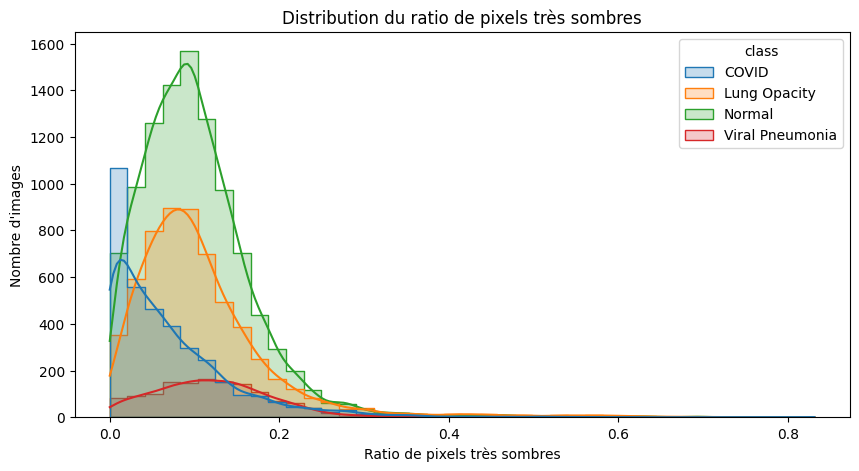

In [42]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=image_level_stats_df,
    x="ratio_pixels_tres_sombres",
    hue="class",
    bins=40,
    kde=True,
    element="step"
)

plt.title("Distribution du ratio de pixels très sombres")
plt.xlabel("Ratio de pixels très sombres")
plt.ylabel("Nombre d'images")
plt.show()

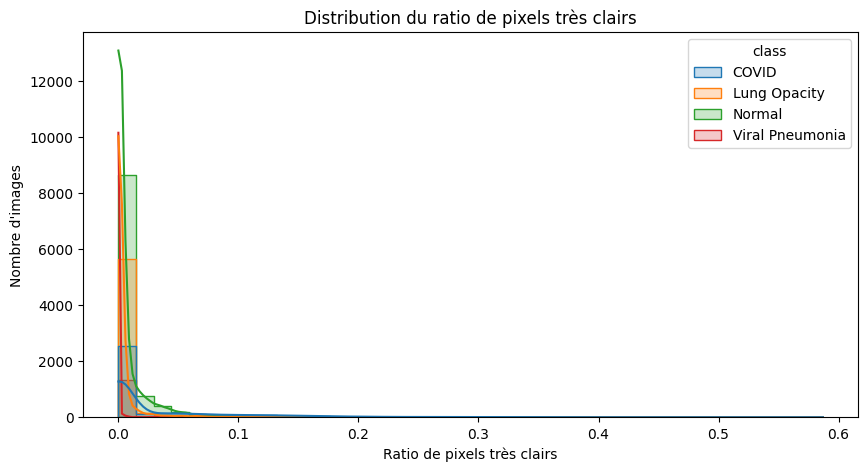

In [43]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=image_level_stats_df,
    x="ratio_pixels_tres_clairs",
    hue="class",
    bins=40,
    kde=True,
    element="step"
)

plt.title("Distribution du ratio de pixels très clairs")
plt.xlabel("Ratio de pixels très clairs")
plt.ylabel("Nombre d'images")
plt.show()